In [18]:
#memasang library yang dibutuhkan
import sys
import requests
import lxml.html as lh
import pandas as pd
%matplotlib inline
import matplotlib.pyplot as plt

In [19]:
#scrape tabel
url='http://pokemondb.net/pokedex/all'
page = requests.get(url)
doc = lh.fromstring(page.content)
tr_elements = doc.xpath('//tr')

In [20]:
#mengetahui jumlah kolom table yang telah dikikis
[len(Z) for Z in tr_elements[:8]]

[10, 10, 10, 10, 10, 10, 10, 10]

In [21]:
#menguraikan table
tr_elements = doc.xpath('//tr')
col=[]
i=0
for t in tr_elements[0]:
    i+=1
    name=t.text_content()
    print ('%d: "%s"'%(i,name))
    col.append((name,[]))

1: "#"
2: "Name"
3: "Type"
4: "Total"
5: "HP"
6: "Attack"
7: "Defense"
8: "Sp. Atk"
9: "Sp. Def"
10: "Speed"


In [22]:
#mengubah tipe data rangkaian ke bentuk tuple
for j in range(11, len(tr_elements)):
    T=tr_elements[j]
    if len(T)!=10:
        break
    i=0
    
    for t in T.iterchildren():
        data=t.text_content()
        if i>0:
            try:
                data=int(data)
            except:
                pass
        col[i][1].append(data)
        i+=1

In [23]:
#mengetahui jumlah baris
[len(B) for (title,B) in col]

[1035, 1035, 1035, 1035, 1035, 1035, 1035, 1035, 1035, 1035]

In [24]:
#mengubah tipe data angkaian ke dictionary lalu membuat dataframe dari dictionary
Dict={title:column for (title, column) in col}
data = pd.DataFrame(Dict)

In [25]:
#Menampilkan data
data.head()

,#,Name,Type,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed
0,008,Wartortle,Water,405,59,63,80,65,80,58
1,009,Blastoise,Water,530,79,83,100,85,105,78
2,009,Blastoise Mega Blastoise,Water,630,79,103,120,135,115,78
3,010,Caterpie,Bug,195,45,30,35,20,20,45
4,011,Metapod,Bug,205,50,20,55,25,25,30


In [26]:
#mengetahui dimensi dataframe
data.shape

(1035, 10)

In [27]:
#mengetahui deskripsi masing-masing kolom
data.describe()

,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed
count,1035.000000,1035.00000,1035.000000,1035.000000,1035.000000,1035.000000,1035.000000
mean,439.015459,70.12657,80.495652,74.657005,72.804831,72.186473,68.744928
std,121.860940,26.74752,32.467849,31.297308,32.646968,28.107679,30.282082
min,175.000000,1.00000,5.000000,5.000000,10.000000,20.000000,5.000000
25%,330.000000,50.00000,55.500000,50.000000,50.000000,50.000000,45.000000
50%,458.000000,68.00000,77.000000,70.000000,65.000000,70.000000,65.000000
75%,515.000000,83.00000,100.000000,90.000000,95.000000,90.000000,90.000000
max,1125.000000,255.00000,190.000000,250.000000,194.000000,250.000000,200.000000


<AxesSubplot:xlabel='HP', ylabel='Attack'>

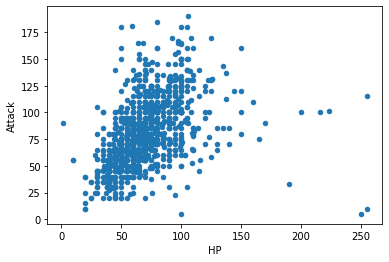

In [28]:
#visualisasi scatter plot antara HP dengan Attack
data.plot.scatter('HP','Attack')

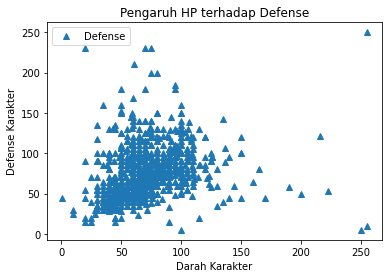

In [29]:
#visualisasi scatter plot antara HP dengan Defense
data.plot(x = "HP", y = "Defense", style = "^")
plt.title("Pengaruh HP terhadap Defense")
plt.xlabel("Darah Karakter")
plt.ylabel("Defense Karakter")
plt.show()

<AxesSubplot:xlabel='Attack', ylabel='Defense'>

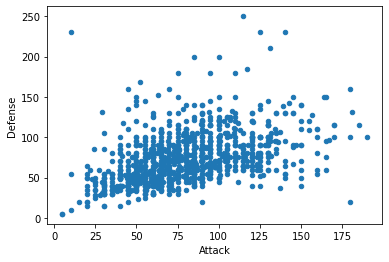

In [30]:
#visualisasi scatter plot antara Attack dengan Defense
data.plot.scatter('Attack','Defense')

<AxesSubplot:xlabel='Attack', ylabel='Speed'>

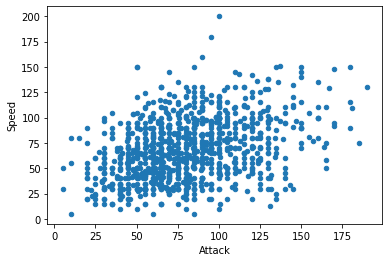

In [31]:
#visualisasi scatter plot antara Attack dengan Speed
data.plot.scatter('Attack','Speed')

<AxesSubplot:xlabel='Attack', ylabel='Sp. Atk'>

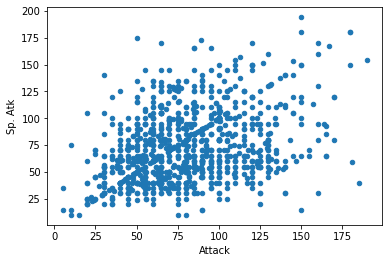

In [33]:
#visualisasi scatter plot antara Attack dengan Sp.Atk
data.plot.scatter('Attack','Sp. Atk')

<AxesSubplot:xlabel='Attack', ylabel='Sp. Def'>

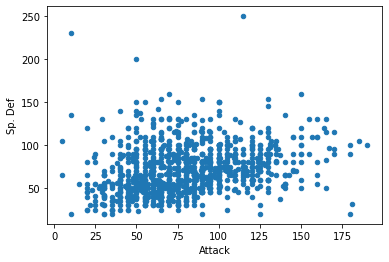

In [34]:
#visualisasi scatter plot antara Attack dengan Sp. Def
data.plot.scatter('Attack','Sp. Def')